In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# DIRECTORY CONFIGURATION
# ============================================================

ROOT = Path.cwd()

SURROGATE_DIR = ROOT / "Data" / "runtime_data" / "surrogate_optimisation"
OUTPUT_DIR = ROOT / "Results" / "initial_final_fid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# INPUT FILES
# Expected structure:
#
# Data/runtime_data_2/surrogate_optimisation/
# ├── GHZ/
# │   ├── 4n_optimisation_summary.json
# │   ├── 6n_optimisation_summary.json
# │   └── 8n_optimisation_summary.json
# ├── W/
# │   ├── 4n_optimisation_summary.json
# │   ├── 6n_optimisation_summary.json
# │   └── 8n_optimisation_summary.json
# └── LC/
#     ├── 4n_optimisation_summary.json
#     ├── 6n_optimisation_summary.json
#     └── 8n_optimisation_summary.json
# ============================================================

STATE_ORDER = ["GHZ", "W", "LC"]
NODE_ORDER = [4, 6, 8]

FILES_SURROGATE = {
    state: {
        n: SURROGATE_DIR / state / f"{n}n.json"
        for n in NODE_ORDER
    }
    for state in STATE_ORDER
}




Current directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code
Surrogate data directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate_optimisation_new
Output directory: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/initial_final_fid
Loading: GHZ, n=4
File   : /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate_optimisation_new/GHZ/4n.json
Initial key  : initial_fidelities
Final key    : final_pytheus_fidelities
Samples      : 1000
Initial mean : 0.167478
Final mean   : 0.999991
Loading: GHZ, n=6
File   : /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Data/runtime_data/surrogate_optimisation_new/GHZ/6n.json
Initial key  : initial_fidelities
Final key    : final_pytheus_fidelities
Samples      : 1000
Initial mean : 0.161499
Final mean   : 0.999991
Loading: GHZ, n=8
File   : /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_co

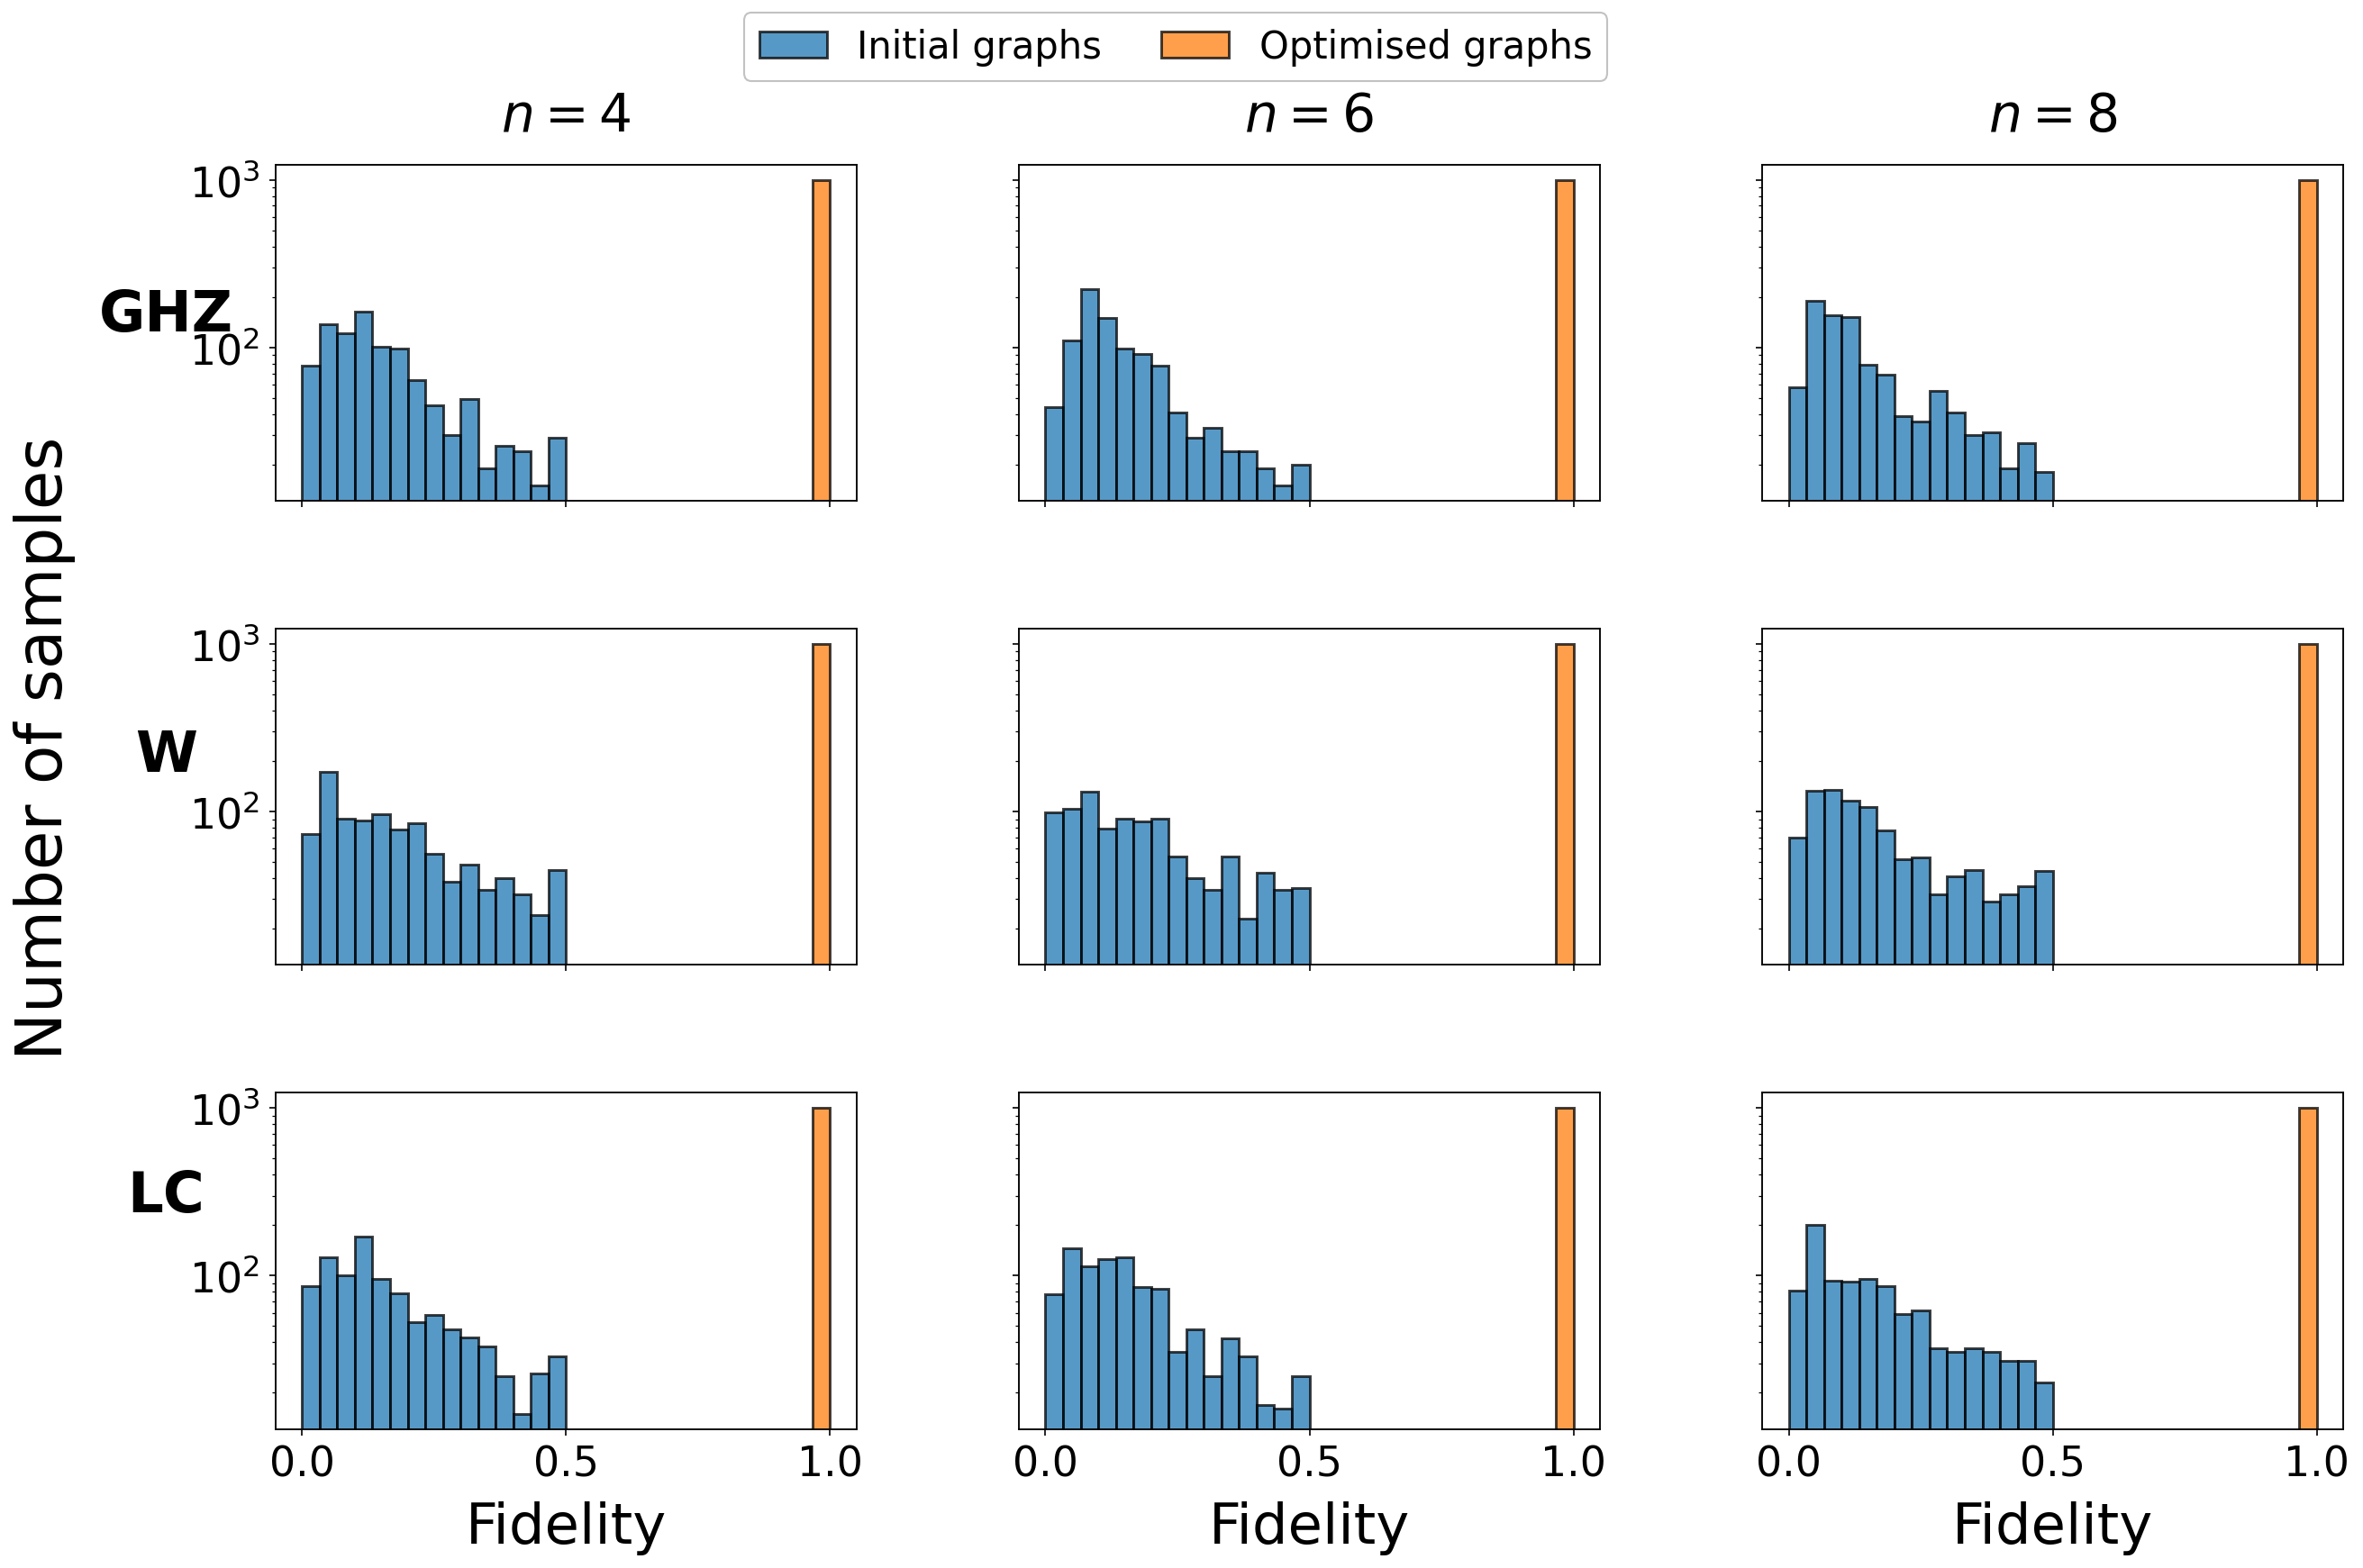

Saved statistics: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/initial_final_fid/initial_final_histogram_statistics_3x3_v2.json
Saved combined PNG: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/initial_final_fid/initial_final_histograms_3x3_grid_v2.png
Saved combined PDF: /home/bo48god/projects/deep_dreaming/PolySurrogate/plotting_code/Results/initial_final_fid/initial_final_histograms_3x3_grid_v2.pdf


In [3]:

print("Current directory:", ROOT)
print("Surrogate data directory:",SURROGATE_DIR)
print("Output directory:", OUTPUT_DIR)



# ============================================================
# USER SETTINGS
# ============================================================

VERSION = 2

SAVE_PNG = True
SAVE_PDF = True
SAVE_DPI = 700

USE_PYTHEUS_INITIAL = True
USE_PYTHEUS_FINAL = True


# ============================================================
# HISTOGRAM SETTINGS
# ============================================================

HIST_BINS = np.linspace(0.0, 1.0, 31)

HIST_RWIDTH = 1.0
HIST_EDGE_COLOR = "black"
HIST_LINEWIDTH = 1.4
HIST_ALPHA = 0.75

INITIAL_LABEL = "Initial graphs"
FINAL_LABEL = "Optimised graphs"

X_LIM = (-0.05, 1.05)

USE_LOG_Y = True
SHOW_GRID = False


# ============================================================
# FIGURE LAYOUT SETTINGS
# ============================================================

FIGSIZE = (18, 12)

WSPACE = 0.28
HSPACE = 0.38

LEFT_MARGIN = 0.13
RIGHT_MARGIN = 0.98
BOTTOM_MARGIN = 0.08
TOP_MARGIN = 0.86

LEGEND_BBOX = (0.5, 0.965)

GLOBAL_YLABEL_X = 0.035
GLOBAL_YLABEL_Y = 0.50

ROW_LABEL_X = 0.085


# ============================================================
# FONT AND STYLE SETTINGS
# ============================================================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,

    "lines.linewidth": 2.0,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    "figure.dpi": 150,
    "savefig.dpi": SAVE_DPI,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.unicode_minus": False,
})


# ============================================================
# EXPLICIT FONT-SIZE CONTROLS
# ============================================================

LABEL_FONTSIZE = 30
TICK_FONTSIZE = 22
LEGEND_FONTSIZE = 20

GLOBAL_YLABEL_FONTSIZE = 34

ROW_LABEL_FONTSIZE = 30
COLUMN_LABEL_FONTSIZE = 28

X_LABELPAD = 8
TICK_PAD = 5


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_fidelities(summary_path: Path):
    """
    Load initial and final fidelities from optimisation summary JSON.
    """
    summary_path = Path(summary_path)

    if not summary_path.exists():
        raise FileNotFoundError(f"Missing file:\n{summary_path}")

    with open(summary_path, "r") as f:
        summary = json.load(f)

    if USE_PYTHEUS_INITIAL and "initial_pytheus_fidelities" in summary:
        initial_key = "initial_pytheus_fidelities"
    else:
        initial_key = "initial_fidelities"

    if USE_PYTHEUS_FINAL and "final_pytheus_fidelities" in summary:
        final_key = "final_pytheus_fidelities"
    elif "final_fidelities" in summary:
        final_key = "final_fidelities"
    elif "best_fidelities" in summary:
        final_key = "best_fidelities"
    elif "optimised_fidelities" in summary:
        final_key = "optimised_fidelities"
    elif "optimized_fidelities" in summary:
        final_key = "optimized_fidelities"
    else:
        raise KeyError(
            f"No final fidelity key found in {summary_path}.\n"
            "Expected one of: final_pytheus_fidelities, final_fidelities, "
            "best_fidelities, optimised_fidelities, optimized_fidelities."
        )

    if initial_key not in summary:
        raise KeyError(
            f"No initial fidelity key found in {summary_path}.\n"
            f"Expected key: {initial_key}"
        )

    initial = np.asarray(summary[initial_key], dtype=np.float64).ravel()
    final = np.asarray(summary[final_key], dtype=np.float64).ravel()

    valid = np.isfinite(initial) & np.isfinite(final)

    initial = initial[valid]
    final = final[valid]

    if len(initial) == 0:
        raise ValueError(f"No valid fidelity values found in {summary_path}")

    if initial.shape != final.shape:
        raise ValueError(
            f"Shape mismatch in {summary_path}: "
            f"{initial_key} shape = {initial.shape}, "
            f"{final_key} shape = {final.shape}"
        )

    return initial, final, initial_key, final_key, summary


def style_axis(ax):
    """
    Apply consistent paper-style axis formatting.
    """
    if SHOW_GRID:
        ax.grid(True, alpha=0.25, linewidth=0.6)
    else:
        ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=TICK_FONTSIZE,
        width=0.8,
        length=3.5,
        direction="out",
        pad=TICK_PAD,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


def save_and_show_figure(fig, output_dir: Path, filename: str):
    """
    Save figure as PNG/PDF and show it in notebook.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = {}

    if SAVE_PNG:
        png_path = output_dir / f"{filename}.png"
        fig.savefig(png_path, dpi=SAVE_DPI, bbox_inches="tight")
        saved_paths["png"] = png_path.resolve()
        print(f"Saved PNG: {png_path.resolve()}")

    if SAVE_PDF:
        pdf_path = output_dir / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        saved_paths["pdf"] = pdf_path.resolve()
        print(f"Saved PDF: {pdf_path.resolve()}")

    plt.show()
    plt.close(fig)

    return saved_paths


def collect_all_data():
    """
    Load all fidelity data into a nested dictionary.

    Returns:
        data[state][n] = {
            "initial": initial,
            "final": final,
            "initial_key": initial_key,
            "final_key": final_key,
            "summary_path": summary_path,
        }
    """
    data = {}
    all_stats = []

    for state in STATE_ORDER:
        data[state] = {}

        for n_nodes in NODE_ORDER:
            summary_path = FILES_SURROGATE[state][n_nodes]

            print("=" * 100)
            print(f"Loading: {state}, n={n_nodes}")
            print(f"File   : {summary_path}")

            if not summary_path.exists():
                print("WARNING: File does not exist. Skipping.")
                continue

            initial, final, initial_key, final_key, summary = load_fidelities(summary_path)

            data[state][n_nodes] = {
                "initial": initial,
                "final": final,
                "initial_key": initial_key,
                "final_key": final_key,
                "summary_path": str(summary_path),
            }

            stats = {
                "target": state,
                "n_nodes": int(n_nodes),
                "num_samples": int(len(initial)),
                "initial_key": initial_key,
                "final_key": final_key,
                "initial_mean": float(np.mean(initial)),
                "initial_std": float(np.std(initial)),
                "initial_min": float(np.min(initial)),
                "initial_max": float(np.max(initial)),
                "final_mean": float(np.mean(final)),
                "final_std": float(np.std(final)),
                "final_min": float(np.min(final)),
                "final_max": float(np.max(final)),
                "summary_path": str(summary_path),
            }

            all_stats.append(stats)

            print(f"Initial key  : {initial_key}")
            print(f"Final key    : {final_key}")
            print(f"Samples      : {len(initial)}")
            print(f"Initial mean : {np.mean(initial):.6f}")
            print(f"Final mean   : {np.mean(final):.6f}")

    return data, all_stats


# ============================================================
# MAIN 3x3 PLOTTING FUNCTION
# ============================================================

def plot_3x3_initial_final_histograms(data):
    """
    Generate one 3x3 histogram figure.

    Rows:
        GHZ, W, LC

    Columns:
        n = 4, n = 6, n = 8
    """
    fig, axes = plt.subplots(
        len(STATE_ORDER),
        len(NODE_ORDER),
        figsize=FIGSIZE,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes)

    for row_idx, state in enumerate(STATE_ORDER):
        for col_idx, n_nodes in enumerate(NODE_ORDER):

            ax = axes[row_idx, col_idx]

            if state not in data or n_nodes not in data[state]:
                ax.axis("off")
                continue

            initial = data[state][n_nodes]["initial"]
            final = data[state][n_nodes]["final"]

            ax.hist(
                initial,
                bins=HIST_BINS,
                alpha=HIST_ALPHA,
                edgecolor=HIST_EDGE_COLOR,
                linewidth=HIST_LINEWIDTH,
                rwidth=HIST_RWIDTH,
            )

            ax.hist(
                final,
                bins=HIST_BINS,
                alpha=HIST_ALPHA,
                edgecolor=HIST_EDGE_COLOR,
                linewidth=HIST_LINEWIDTH,
                rwidth=HIST_RWIDTH,
            )

            if USE_LOG_Y:
                ax.set_yscale("log")

            ax.set_xlim(X_LIM)

            style_axis(ax)

            if row_idx == 0:
                ax.set_title(
                    rf"$n = {n_nodes}$",
                    fontsize=COLUMN_LABEL_FONTSIZE,
                    pad=18,
                )

            if row_idx == len(STATE_ORDER) - 1:
                ax.set_xlabel(
                    "Fidelity",
                    fontsize=LABEL_FONTSIZE,
                    labelpad=X_LABELPAD,
                )
            else:
                ax.set_xlabel("")

            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    # Global y-label
    fig.text(
        GLOBAL_YLABEL_X,
        GLOBAL_YLABEL_Y,
        "Number of samples",
        va="center",
        ha="center",
        rotation="vertical",
        fontsize=GLOBAL_YLABEL_FONTSIZE,
    )

    # Row labels
    for row_idx, state in enumerate(STATE_ORDER):
        row_ax = axes[row_idx, 0]
        pos = row_ax.get_position()
        y_center = 0.5 * (pos.y0 + pos.y1)

        fig.text(
            ROW_LABEL_X,
            y_center,
            state,
            va="center",
            ha="center",
            fontsize=ROW_LABEL_FONTSIZE,
            fontweight="bold",
        )

    # Global legend only
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    legend_handles = [
        Patch(
            facecolor=color_cycle[0],
            edgecolor=HIST_EDGE_COLOR,
            linewidth=HIST_LINEWIDTH,
            alpha=HIST_ALPHA,
            label=INITIAL_LABEL,
        ),
        Patch(
            facecolor=color_cycle[1],
            edgecolor=HIST_EDGE_COLOR,
            linewidth=HIST_LINEWIDTH,
            alpha=HIST_ALPHA,
            label=FINAL_LABEL,
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=LEGEND_BBOX,
        ncol=2,
        frameon=True,
        framealpha=0.95,
        edgecolor="0.75",
        fontsize=LEGEND_FONTSIZE,
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.3,
        columnspacing=1.6,
    )

    fig.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
        wspace=WSPACE,
        hspace=HSPACE,
    )

    filename = f"initial_final_histograms_3x3_grid_v{VERSION}"

    saved_paths = save_and_show_figure(
        fig=fig,
        output_dir=OUTPUT_DIR,
        filename=filename,
    )

    return saved_paths


# ============================================================
# MAIN SCRIPT
# ============================================================

data, all_stats = collect_all_data()

saved_paths = plot_3x3_initial_final_histograms(data)

stats_path = OUTPUT_DIR / f"initial_final_histogram_statistics_3x3_v{VERSION}.json"

with open(stats_path, "w") as f:
    json.dump(all_stats, f, indent=4)

print("=" * 100)
print(f"Saved statistics: {stats_path.resolve()}")

if "png" in saved_paths:
    print(f"Saved combined PNG: {saved_paths['png']}")
if "pdf" in saved_paths:
    print(f"Saved combined PDF: {saved_paths['pdf']}")

print("=" * 100)